### In Simple LR -> we have one independent feature
### In Multiple LR -> we have more than one independent features

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
California = pd.read_csv("california_housing.csv")

In [4]:
California

,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,0,2.3859,15.0,3.827160,1.112100,1280.0,2.486989,34.60,-120.12,0.980
1,1,3.7188,17.0,6.013373,1.054217,1504.0,3.813084,38.69,-121.22,0.946
2,2,4.7750,27.0,6.535604,1.103175,1061.0,2.464602,34.71,-120.45,1.576
3,3,2.4138,16.0,3.350203,0.965432,1255.0,2.089286,32.66,-117.09,1.336
4,4,3.7500,52.0,4.284404,1.069246,1793.0,1.604790,37.80,-122.41,4.500
...,...,...,...,...,...,...,...,...,...,...
37132,37132,3.3438,50.0,4.936508,1.079365,1775.0,3.022222,34.19,-118.36,1.856
37133,37133,3.7308,26.0,5.087533,0.966019,1006.0,4.316901,37.32,-121.86,1.588
37134,37134,4.1716,52.0,4.678862,1.101485,1156.0,1.431734,37.75,-122.44,3.387
37135,37135,2.7143,16.0,5.710074,1.068376,584.0,2.803659,38.40,-120.98,1.592


In [6]:
#X = California.drop("MedHouseVal", axis=1)
#y = California["MedHouseVaal"]

In [7]:
California.head()

,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,0,2.3859,15.0,3.827160,1.112100,1280.0,2.486989,34.60,-120.12,0.980
1,1,3.7188,17.0,6.013373,1.054217,1504.0,3.813084,38.69,-121.22,0.946
2,2,4.7750,27.0,6.535604,1.103175,1061.0,2.464602,34.71,-120.45,1.576
3,3,2.4138,16.0,3.350203,0.965432,1255.0,2.089286,32.66,-117.09,1.336
4,4,3.7500,52.0,4.284404,1.069246,1793.0,1.604790,37.80,-122.41,4.500


In [8]:
dataset = California.copy()
print(dataset.head())

   id  MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0   0  2.3859      15.0  3.827160   1.112100      1280.0  2.486989     34.60   
1   1  3.7188      17.0  6.013373   1.054217      1504.0  3.813084     38.69   
2   2  4.7750      27.0  6.535604   1.103175      1061.0  2.464602     34.71   
3   3  2.4138      16.0  3.350203   0.965432      1255.0  2.089286     32.66   
4   4  3.7500      52.0  4.284404   1.069246      1793.0  1.604790     37.80   

   Longitude  MedHouseVal  
0    -120.12        0.980  
1    -121.22        0.946  
2    -120.45        1.576  
3    -117.09        1.336  
4    -122.41        4.500  


In [9]:
dataset.head()

,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,0,2.3859,15.0,3.827160,1.112100,1280.0,2.486989,34.60,-120.12,0.980
1,1,3.7188,17.0,6.013373,1.054217,1504.0,3.813084,38.69,-121.22,0.946
2,2,4.7750,27.0,6.535604,1.103175,1061.0,2.464602,34.71,-120.45,1.576
3,3,2.4138,16.0,3.350203,0.965432,1255.0,2.089286,32.66,-117.09,1.336
4,4,3.7500,52.0,4.284404,1.069246,1793.0,1.604790,37.80,-122.41,4.500


### As we have multiple independent features -> So we will need a multiple linear regression model to implement

In [10]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 37137 entries, 0 to 37136
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           37137 non-null  int64  
 1   MedInc       37137 non-null  float64
 2   HouseAge     37137 non-null  float64
 3   AveRooms     37137 non-null  float64
 4   AveBedrms    37137 non-null  float64
 5   Population   37137 non-null  float64
 6   AveOccup     37137 non-null  float64
 7   Latitude     37137 non-null  float64
 8   Longitude    37137 non-null  float64
 9   MedHouseVal  37137 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 2.8 MB


## Missing Values

In [11]:
dataset.isnull().sum()

id             0
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [12]:
dataset.describe()

,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,37137.00000,37137.000000,37137.000000,37137.000000,37137.000000,37137.000000,37137.000000,37137.000000,37137.000000,37137.000000
mean,18568.00000,3.851029,26.057005,5.163124,1.062204,1660.778919,2.831243,35.570030,-119.554329,2.079751
std,10720.67281,1.803167,12.158221,1.206242,0.096490,1302.469608,2.702413,2.083179,1.974028,1.158571
min,0.00000,0.499900,2.000000,0.851064,0.500000,3.000000,0.950000,32.550000,-124.350000,0.149990
25%,9284.00000,2.602300,17.000000,4.357522,1.020305,952.000000,2.394495,33.930000,-121.800000,1.208000
50%,18568.00000,3.515600,25.000000,5.068611,1.054545,1383.000000,2.744828,34.190000,-118.450000,1.808000
75%,27852.00000,4.699700,35.000000,5.858597,1.088825,1856.000000,3.125313,37.700000,-118.020000,2.660000
max,37136.00000,15.000100,52.000000,28.837607,5.873181,35682.000000,502.990610,41.950000,-114.550000,5.000010


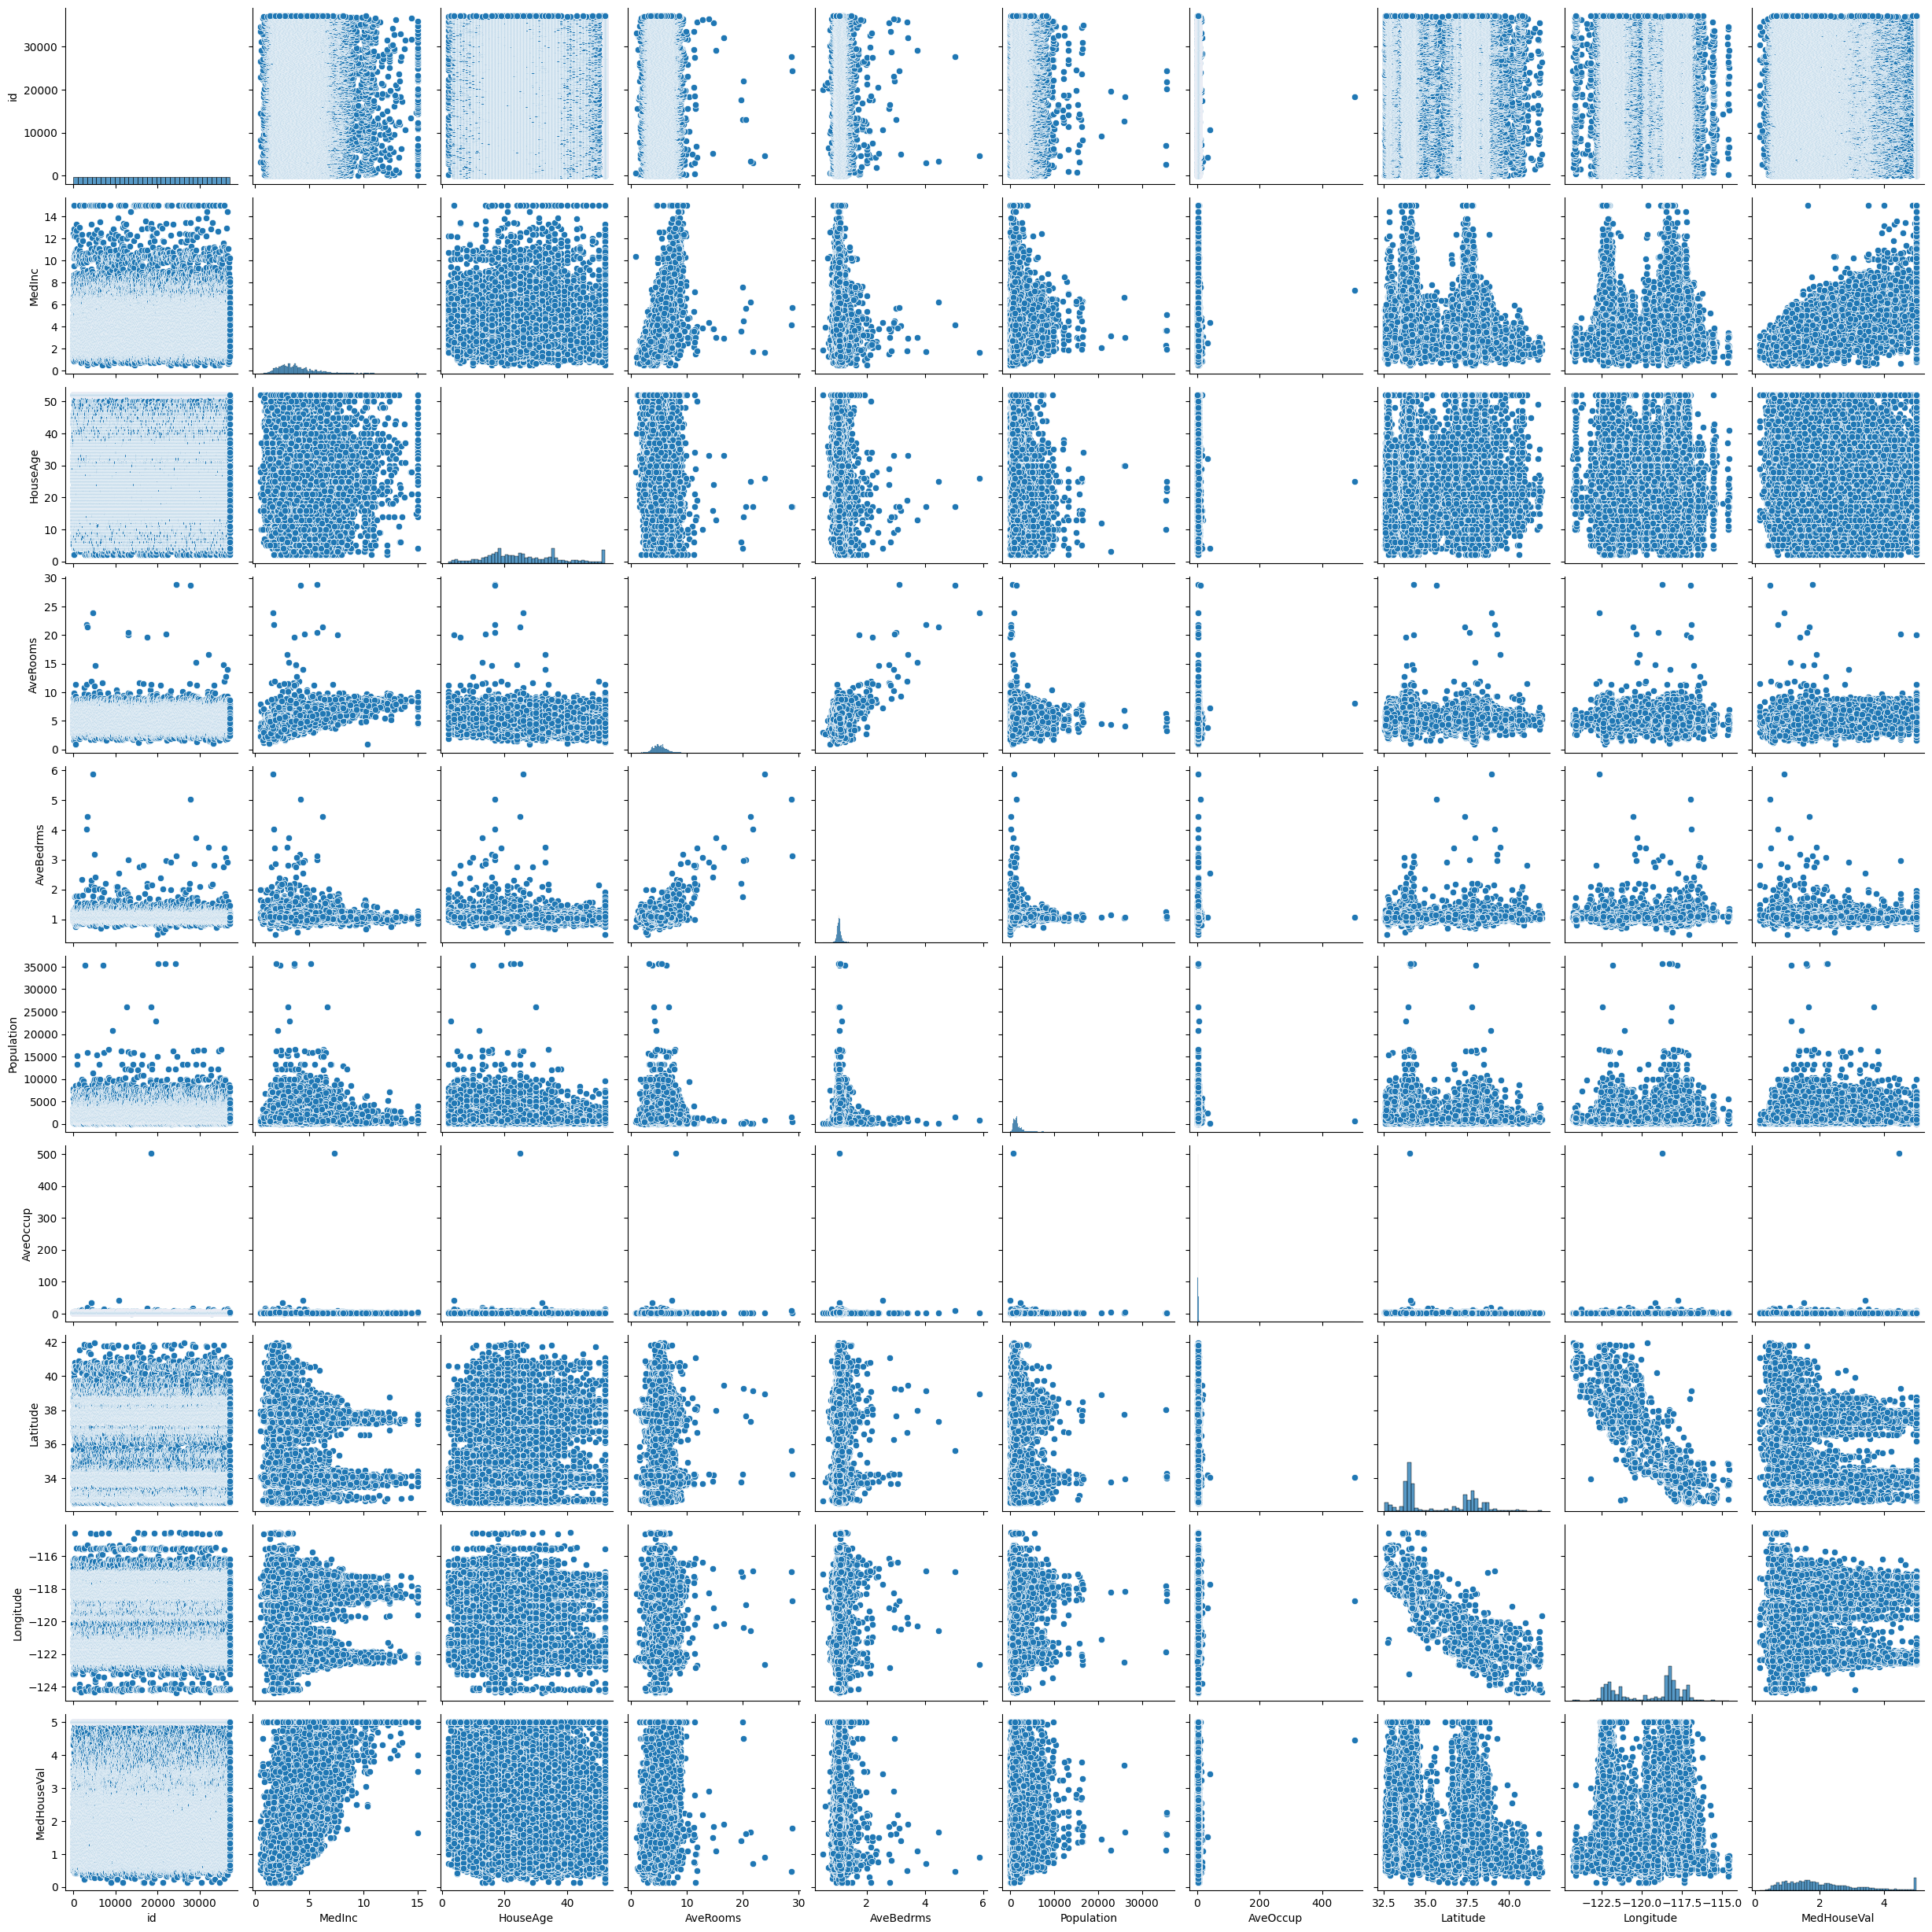

In [13]:
sns.pairplot(dataset)

In [14]:
dataset.corr()

,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
id,1.000000,0.000312,-0.001248,-0.000506,-0.004370,0.002427,-0.000980,-0.000911,0.001887,-0.001358
MedInc,0.000312,1.000000,-0.080542,0.699994,-0.127169,-0.008552,-0.000885,-0.060463,-0.043742,0.701925
HouseAge,-0.001248,-0.080542,1.000000,-0.156625,-0.056960,-0.235459,-0.002792,0.021071,-0.090394,0.103210
AveRooms,-0.000506,0.699994,-0.156625,1.000000,0.174753,-0.038099,0.023858,0.095169,-0.088184,0.366727
AveBedrms,-0.004370,-0.127169,-0.056960,0.174753,1.000000,-0.007120,-0.009257,0.026142,0.015218,-0.067487
Population,0.002427,-0.008552,-0.235459,-0.038099,-0.007120,1.000000,0.022825,-0.069944,0.071085,-0.038479
AveOccup,-0.000980,-0.000885,-0.002792,0.023858,-0.009257,0.022825,1.000000,-0.032199,0.037118,-0.048475
Latitude,-0.000911,-0.060463,0.021071,0.095169,0.026142,-0.069944,-0.032199,1.000000,-0.937370,-0.116499
Longitude,0.001887,-0.043742,-0.090394,-0.088184,0.015218,0.071085,0.037118,-0.937370,1.000000,-0.056742
MedHouseVal,-0.001358,0.701925,0.103210,0.366727,-0.067487,-0.038479,-0.048475,-0.116499,-0.056742,1.000000


<Axes: >

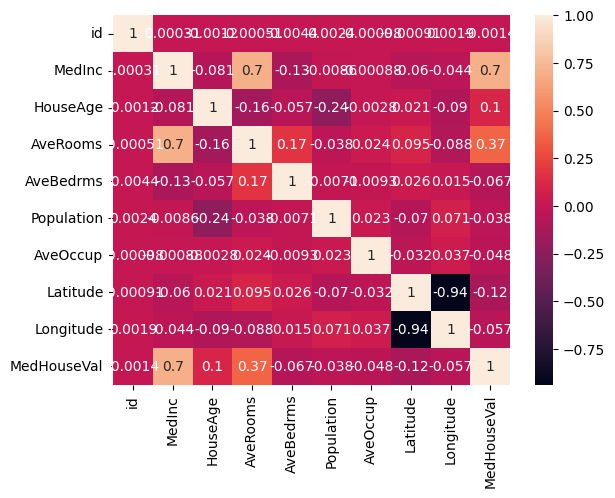

In [15]:
sns.heatmap(dataset.corr(), annot=True)

## Creating a Multiple Linear Regression Model

In [16]:
dataset.head()

,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,0,2.3859,15.0,3.827160,1.112100,1280.0,2.486989,34.60,-120.12,0.980
1,1,3.7188,17.0,6.013373,1.054217,1504.0,3.813084,38.69,-121.22,0.946
2,2,4.7750,27.0,6.535604,1.103175,1061.0,2.464602,34.71,-120.45,1.576
3,3,2.4138,16.0,3.350203,0.965432,1255.0,2.089286,32.66,-117.09,1.336
4,4,3.7500,52.0,4.284404,1.069246,1793.0,1.604790,37.80,-122.41,4.500


In [17]:
## Remove ID
dataset = dataset.drop('id', axis=1)

In [18]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,2.3859,15.0,3.827160,1.112100,1280.0,2.486989,34.60,-120.12,0.980
1,3.7188,17.0,6.013373,1.054217,1504.0,3.813084,38.69,-121.22,0.946
2,4.7750,27.0,6.535604,1.103175,1061.0,2.464602,34.71,-120.45,1.576
3,2.4138,16.0,3.350203,0.965432,1255.0,2.089286,32.66,-117.09,1.336
4,3.7500,52.0,4.284404,1.069246,1793.0,1.604790,37.80,-122.41,4.500


In [19]:
## Divide data into dependent and independent features(8)
X = dataset.iloc[:,:-1] # Except last take every column -> Independent features
Y = dataset.iloc[:,-1] # Take only last column -> Dependent feature

In [20]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.3859,15.0,3.827160,1.112100,1280.0,2.486989,34.60,-120.12
1,3.7188,17.0,6.013373,1.054217,1504.0,3.813084,38.69,-121.22
2,4.7750,27.0,6.535604,1.103175,1061.0,2.464602,34.71,-120.45
3,2.4138,16.0,3.350203,0.965432,1255.0,2.089286,32.66,-117.09
4,3.7500,52.0,4.284404,1.069246,1793.0,1.604790,37.80,-122.41


In [26]:
X = California.drop("MedHouseVal", axis=1)
y = California["MedHouseVal"]

In [27]:
Y.head()

0    0.980
1    0.946
2    1.576
3    1.336
4    4.500
Name: MedHouseVal, dtype: float64

## Train Test Split

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=10
)

In [29]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((24881, 9), (12256, 9), (24881,), (12256,))

## Standardize the dataset

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [31]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
X_train

array([[ 1.53875612,  0.29386587, -0.00239813, ..., -0.38446147,
        -0.70576264,  0.60702125],
       [ 0.37294116, -1.63921095,  2.13153275, ..., -0.31510958,
        -1.363756  ,  1.21019812],
       [-1.29925574,  0.35938829,  1.3107901 , ...,  0.10892068,
        -0.65293105,  0.59688382],
       ...,
       [ 0.87550382,  0.28494601,  2.13153275, ..., -0.02267654,
         1.03767963, -1.46101377],
       [ 0.98561116, -1.19943983, -0.57691799, ..., -0.29747488,
        -0.68174828,  1.19499198],
       [-0.08807507, -0.76688168, -0.74106652, ..., -0.1111801 ,
         1.46513517, -0.91866145]], shape=(24881, 9))

In [33]:
X_test

array([[ 0.10549772,  0.2473945 ,  0.98249304, ..., -0.05330753,
        -0.80182006,  0.63236481],
       [ 0.34844182,  0.80048088,  1.06456731, ..., -0.14060961,
        -0.67694541,  0.59181511],
       [-0.16567187, -0.26147801,  1.22871583, ...,  0.27132376,
        -0.69135402,  0.68305194],
       ...,
       [ 0.76148405,  0.51856925, -0.57691799, ..., -0.05503762,
        -0.65773392,  0.48537213],
       [-0.45649682,  1.69555028, -0.24862093, ..., -0.07351169,
        -0.70576264,  0.75401393],
       [-0.23861099,  0.16584936,  0.49004745, ...,  0.23991918,
        -0.83544016,  0.80976978]], shape=(12256, 9))

## Model Training

In [34]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [35]:
regression

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Fit the regression model with Training Data

In [37]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
# Coefficient(Slope)
regression.coef_

array([ 3.91500952e-04,  8.79845003e-01,  1.04882440e-01, -1.78028803e-01,
        9.76203731e-02, -1.62674632e-02, -3.62878734e-02, -8.41315343e-01,
       -8.19400284e-01])

In [39]:
# Intercepts
regression.intercept_

np.float64(2.0880572565411404)

## Prediction for the Test Data

In [40]:
y_pred = regression.predict(X_test)


In [41]:
y_test

19751    2.333
22359    3.206
16840    1.828
32753    0.588
532      1.750
         ...  
8980     0.980
21628    0.932
26793    2.269
13718    2.542
16057    1.958
Name: MedHouseVal, Length: 12256, dtype: float64

In [42]:
y_pred

array([2.58315567, 2.85916451, 1.96175919, ..., 2.54432091, 3.2811966 ,
       2.26853754], shape=(12256,))

In [43]:
# Now from y_pred and y_test, we will find the accuracy, r2 score and  all
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(np.sqrt(mean_squared_error(y_test, y_pred)))

0.5255793402316784
0.5297443032481037
0.724968509820722


In [44]:
# We have to reduce the above errors

In [46]:
## R Square and Adjusted R Square
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print(score)

0.6035225387214429


In [47]:
## Adjusted R square
1 - (1 - score)*(len(y_test)-1) / (len(y_test) - X_test.shape[1]-1)

0.603231154012027

In [48]:
# Problem with multiple linear regression, if the model is not linearly scattered

## Assumptions

Text(0, 0.5, 'Test Predicted Data')

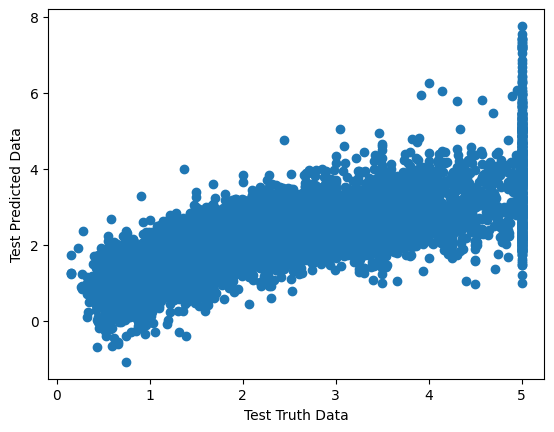

In [49]:
plt.scatter(y_test, y_pred)
plt.xlabel("Test Truth Data")
plt.ylabel("Test Predicted Data")

## Residuals

In [50]:
residuals = y_test - y_pred

In [51]:
residuals

19751   -0.250156
22359    0.346835
16840   -0.133759
32753   -0.301238
532     -0.414649
           ...   
8980     0.018119
21628   -0.957618
26793   -0.275321
13718   -0.739197
16057   -0.310538
Name: MedHouseVal, Length: 12256, dtype: float64

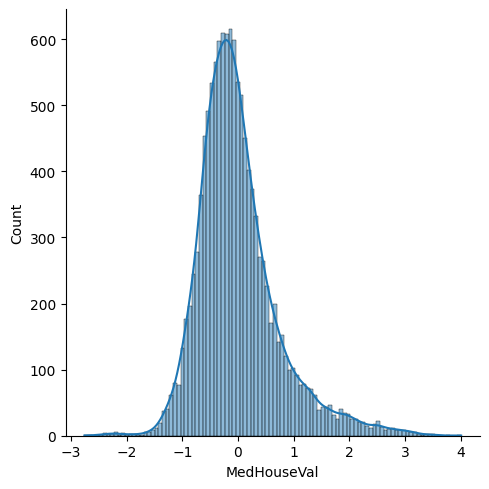

In [52]:
sns.displot(residuals, kde=True)

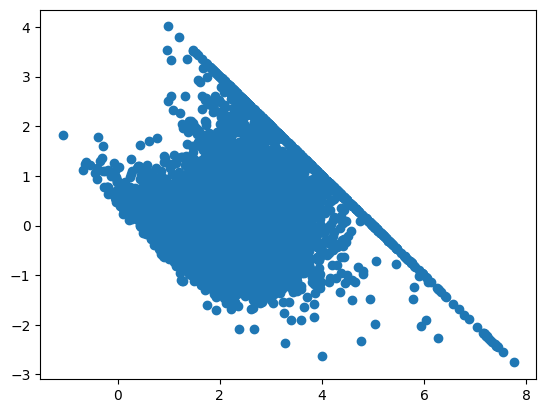

In [53]:
## Trying to plot the rediduals with the predicted values
plt.scatter(y_pred, residuals)

In [54]:
## Accuracy is coming less so this model is not the best model for the prediction of given dataset.
# So we have to run different models as well

## After Model Creation

## Pickling

Python pickle module is used for serialising and de-serialising a Python object structure. Any object in Python can be pickled so that it can be saved on disk. What pickle does is that it "serialises the object first before writing it to file. Pickling is a way to convert a python object (list. dict, etc.) into a character stream. The idea is that this character stream contains all the information necessary to reconstruct the object in another python script

In [56]:
import pickle
pickle.dump(regression, open('regression.pkl', 'wb'))

In [57]:
model = pickle.load(open('regression.pkl', 'rb'))

In [58]:
model.predict(X_test)

array([2.58315567, 2.85916451, 1.96175919, ..., 2.54432091, 3.2811966 ,
       2.26853754], shape=(12256,))